<h1 style='text-align: center; font-family: Colonna MT; font-size: 45px; font-weight: 600'> Retail Cohort Analysis | Tracking Customer Behavior <br>Exploratory Data Analysis (EDA)<br><span style='color: crimson; text-align: center; font-family: Cursive; font-size: 15px; font-weight: 600'>Authour: Chausiku Kassimu | Email: Chausikukassimu1@gmail.com | WhatsApp: +255 790 708 450</span></h1>

----

<h1 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>1.0. IMPORT REQUIRED LIBRARIES</h1>

In [32]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    import datetime as dt
    import seaborn as sns
    import pandas as pd
    import numpy as np
    import warnings  
    import random
    import math
    import re

    plt.rcParams.update({'font.size': 10 })
    pd.set_option('display.float_format', lambda x: '%.2f' % x)
    pd.set_option('display.max_columns', 100)
    warnings.simplefilter("ignore") 
    

<h1 style='font-family: Bradley Hand ITC; font-weight: 600; font-size: 20px; text-align: left'>2.0. IMPORTING AND PREPARE DATASETS </h1>

In [33]:
if __name__ == "__main__":
    df = pd.read_csv("Datasets/Scanner Dataset (2025).csv")
    df.Date = pd.to_datetime(df.Date, format='%d/%m/%Y')
    display(df.head(10))

,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount
0,2016-01-02,2547,1,X52,0EM7L,1.00,3.13
1,2016-01-02,822,2,2ML,68BRQ,1.00,5.46
2,2016-01-02,3686,3,0H2,CZUZX,1.00,6.35
3,2016-01-02,3719,4,0H2,549KK,1.00,5.59
4,2016-01-02,9200,5,0H2,K8EHH,1.00,6.88
5,2016-01-02,5010,6,JPI,GVBRC,1.00,10.77
6,2016-01-02,1666,7,XG4,AHAE7,1.00,3.65
7,2016-01-02,1666,7,FEW,AHZNS,1.00,8.21
8,2016-01-02,1253,8,0H2,9STQJ,1.00,8.25
9,2016-01-02,5541,9,N5F,7IE9S,1.00,8.18


<h1 style='font-family: Bradley Hand ITC; font-size: 20px; font-weight: 600'> 3.0: DATA OVERVIEW AND QUALITY CHECKS</h1>

<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 3.1: DATA SHAPE AND COLUMNS</h3>

In [6]:
df.shape

(131706, 7)

In [7]:
df.columns

Index(['Date', 'Customer_ID', 'Transaction_ID', 'SKU_Category', 'SKU',
       'Quantity', 'Sales_Amount'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131706 entries, 0 to 131705
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Date            131706 non-null  datetime64[ns]
 1   Customer_ID     131706 non-null  int64         
 2   Transaction_ID  131706 non-null  int64         
 3   SKU_Category    131706 non-null  object        
 4   SKU             131706 non-null  object        
 5   Quantity        131706 non-null  float64       
 6   Sales_Amount    131706 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 7.0+ MB


<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 3.2: COLUMNS SUMMARIES</h3>

In [9]:
def column_summaries(df: pd.DataFrame) -> pd.DataFrame:
    summary_data = []
    for col_name in df.columns:
        col_dtype = df[col_name].dtype
        num_of_nulls = df[col_name].isnull().sum()
        num_of_non_nulls = df[col_name].notnull().sum()
        num_of_distinct_values = df[col_name].nunique()
        
        if num_of_distinct_values <= 10:
            distinct_values_counts = df[col_name].value_counts().to_dict()
        else:
            top_10_values_counts = df[col_name].value_counts().head(10).to_dict()
            distinct_values_counts = {k: v for k, v in sorted(top_10_values_counts.items(), key=lambda item: item[1], reverse=True)}

        summary_data.append({
            'col_name': col_name,
            'col_dtype': col_dtype,
            'num_of_nulls': num_of_nulls,
            'num_of_non_nulls': num_of_non_nulls,
            'num_of_distinct_values': num_of_distinct_values,
            'distinct_values_counts': distinct_values_counts
        })
    
    return pd.DataFrame(summary_data)

if __name__ == "__main__":
    results = column_summaries(df)
    display(results)

,col_name,col_dtype,num_of_nulls,num_of_non_nulls,num_of_distinct_values,distinct_values_counts
0,Date,datetime64[ns],0,131706,363,"{2016-09-23 00:00:00: 638, 2016-12-15 00:00:00..."
1,Customer_ID,int64,0,131706,22625,"{1660: 228, 1665: 222, 17104: 218, 1685: 191, ..."
2,Transaction_ID,int64,0,131706,64682,"{19098: 21, 1348: 21, 42295: 20, 28731: 19, 16..."
3,SKU_Category,object,0,131706,187,"{'N8U': 10913, 'R6E': 5099, 'LPF': 5062, 'P42'..."
4,SKU,object,0,131706,5242,"{'UNJKW': 2007, 'COWU2': 791, 'OV1P9': 737, 'M..."
5,Quantity,float64,0,131706,83,"{1.0: 102741, 2.0: 20173, 3.0: 6150, 4.0: 954,..."
6,Sales_Amount,float64,0,131706,3233,"{2.11: 1852, 6.75: 1718, 6.35: 1283, 4.57: 123..."


<h1 style='font-family: Bradley Hand ITC; font-size: 20px; font-weight: 600'> 4.0: COHORTS ANALYSIS — 2026</h1>

<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 4.1: DATA AGGRAGATION BY DATE & CUSTOMER</h3>

In [10]:
if __name__ == "__main__":
    df = (df.groupby(["Date", "Customer_ID"])
          .agg({
              'Transaction_ID': 'max',
              'SKU_Category': 'max',
              'SKU': 'max',
              'Quantity': 'sum',
              'Sales_Amount': 'sum'
          })
          .reset_index()
       )
    
    display(df.head(10))

,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount
0,2016-01-02,3,90,TW8,Y1M2E,4.00,10.92
1,2016-01-02,178,84,R6E,HO1M5,2.00,58.99
2,2016-01-02,195,107,LGI,VY2UB,2.00,13.10
3,2016-01-02,343,134,XG4,ZSVWE,1.00,6.75
4,2016-01-02,399,136,P42,XJLWY,2.00,10.43
5,2016-01-02,427,91,R6E,LKDTY,3.00,15.19
6,2016-01-02,454,127,0H2,O1X0L,1.00,6.07
7,2016-01-02,473,58,J4R,MZL43,5.00,16.87
8,2016-01-02,592,13,YMJ,YJTMP,2.00,20.65
9,2016-01-02,708,50,0H2,K8EHH,1.00,6.88


<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 4.2: EXTRACTING FIRST CUSTOMER ACQUISITION MONTH & RETURNING MONTHS</h3>

In [37]:
#df['Date'] = pd.to_datetime(df['Date'])                                     # Ensure Date column is proper datetime
df['tx_month'] = df['Date'].apply(lambda x: dt.date(x.year, x.month, 1))     # Create transaction month (first day of the month)
df['acq_month'] = df.groupby('Customer_ID')['tx_month'].transform('min')     # Acquisition month = first month a customer appears
df.loc[df['tx_month'] != df['acq_month']].head()                             # View rows where tx_month ≠ acq_month (i.e., returning months)

,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,tx_month,acq_month
10000,2016-02-01,3652,4848,HTR,5X0PS,2.00,114.70,2016-02-01,2016-01-01
10001,2016-02-01,3456,4849,H15,T4G9H,1.00,8.12,2016-02-01,2016-01-01
10002,2016-02-01,3456,4849,H15,E3PAN,1.00,8.32,2016-02-01,2016-01-01
10005,2016-02-01,366,4852,J4R,D7CQM,1.00,7.46,2016-02-01,2016-01-01
10006,2016-02-01,366,4852,A38,VGIW5,1.00,8.18,2016-02-01,2016-01-01


<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 4.3: CREATING COHORT INDEX</h3>

In [38]:
def diff_month(x):
    d1 = x['tx_month']
    d2 = x['acq_month']
    return ((d1.year - d2.year) * 12 + (d1.month - d2.month)) + 1

if __name__ == "__main__":
    df['cohort_idx'] = df.apply(diff_month, axis=1)
    display(df.head(10))

,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,tx_month,acq_month,cohort_idx
0,2016-01-02,2547,1,X52,0EM7L,1.00,3.13,2016-01-01,2016-01-01,1
1,2016-01-02,822,2,2ML,68BRQ,1.00,5.46,2016-01-01,2016-01-01,1
2,2016-01-02,3686,3,0H2,CZUZX,1.00,6.35,2016-01-01,2016-01-01,1
3,2016-01-02,3719,4,0H2,549KK,1.00,5.59,2016-01-01,2016-01-01,1
4,2016-01-02,9200,5,0H2,K8EHH,1.00,6.88,2016-01-01,2016-01-01,1
5,2016-01-02,5010,6,JPI,GVBRC,1.00,10.77,2016-01-01,2016-01-01,1
6,2016-01-02,1666,7,XG4,AHAE7,1.00,3.65,2016-01-01,2016-01-01,1
7,2016-01-02,1666,7,FEW,AHZNS,1.00,8.21,2016-01-01,2016-01-01,1
8,2016-01-02,1253,8,0H2,9STQJ,1.00,8.25,2016-01-01,2016-01-01,1
9,2016-01-02,5541,9,N5F,7IE9S,1.00,8.18,2016-01-01,2016-01-01,1


<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 4.4: CREATING COHORT MATRIX</h3>

In [39]:
def build_cohort_matrices(df, id_col='Customer_ID', agg_func=pd.Series.nunique):
    # --- 1. Aggregate customers per cohort month ---
    cohort_data = (
        df.groupby(['acq_month', 'cohort_idx'])[id_col]
          .apply(agg_func)
          .reset_index()
    )

    # --- 2. Pivot into cohort count matrix ---
    cohort_counts = cohort_data.pivot_table(
        index='acq_month',
        columns='cohort_idx',
        values=id_col
    )

    # --- 3. Calculate retention percentages ---
    cohort_sizes = cohort_counts.iloc[:, 0]
    retention_matrix = cohort_counts.divide(cohort_sizes, axis=0)
    retention_matrix = (retention_matrix * 100).round(2)

    return cohort_counts, retention_matrix

if __name__ == "__main__":
    cohort_counts, retention_matrix = build_cohort_matrices(df)
    display(retention_matrix.fillna('-'))

cohort_idx,1,2,3,4,5,6,7,8,9,10,11,12
acq_month,,,,,,,,,,,,
2016-01-01,100.00,38.46,30.18,17.58,7.83,5.80,4.48,4.03,2.65,1.65,1.21,1.18
2016-02-01,100.00,21.52,13.10,6.62,4.28,3.06,3.06,2.57,0.99,0.81,0.63,-
2016-03-01,100.00,28.24,24.64,22.71,20.06,19.72,20.06,19.38,19.42,20.14,-,-
2016-04-01,100.00,28.81,25.05,21.88,22.40,23.55,22.40,22.44,22.99,-,-,-
2016-05-01,100.00,23.84,21.29,19.23,21.55,20.98,19.84,19.92,-,-,-,-
2016-06-01,100.00,17.72,17.46,17.85,17.72,17.65,19.12,-,-,-,-,-
2016-07-01,100.00,14.18,15.09,15.58,15.00,16.57,-,-,-,-,-,-
2016-08-01,100.00,15.38,13.02,13.49,11.89,-,-,-,-,-,-,-
2016-09-01,100.00,19.02,16.18,18.28,-,-,-,-,-,-,-,-


In [40]:
display(cohort_counts.fillna('-'))

cohort_idx,1,2,3,4,5,6,7,8,9,10,11,12
acq_month,,,,,,,,,,,,
2016-01-01,3396.00,1306.00,1025.00,597.00,266.00,197.00,152.00,137.00,90.00,56.00,41.00,40.00
2016-02-01,2221.00,478.00,291.00,147.00,95.00,68.00,68.00,57.00,22.00,18.00,14.00,-
2016-03-01,2642.00,746.00,651.00,600.00,530.00,521.00,530.00,512.00,513.00,532.00,-,-
2016-04-01,2527.00,728.00,633.00,553.00,566.00,595.00,566.00,567.00,581.00,-,-,-
2016-05-01,2626.00,626.00,559.00,505.00,566.00,551.00,521.00,523.00,-,-,-,-
2016-06-01,1569.00,278.00,274.00,280.00,278.00,277.00,300.00,-,-,-,-,-
2016-07-01,1213.00,172.00,183.00,189.00,182.00,201.00,-,-,-,-,-,-
2016-08-01,1060.00,163.00,138.00,143.00,126.00,-,-,-,-,-,-,-
2016-09-01,1625.00,309.00,263.00,297.00,-,-,-,-,-,-,-,-


<h3 style='font-family: Bradley Hand ITC; font-size: 18px; font-weight: 600'> 4.5: COHORT VISUALIZATIONS</h3>

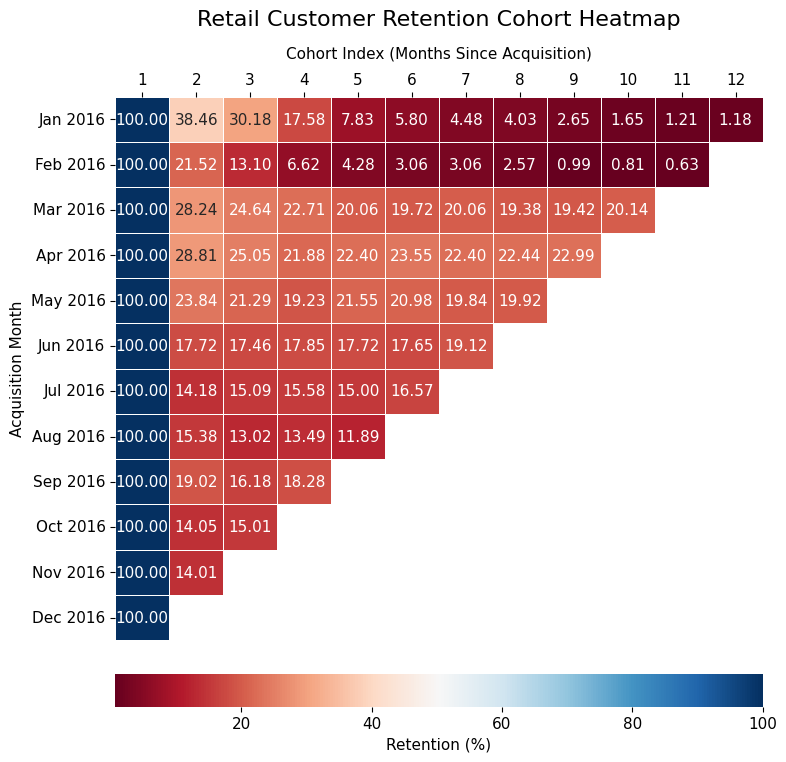

In [41]:
def plot_cohort_heatmap(retention_matrix, title="Cohort Retention Heatmap", cbar_label="Retention (%)"):
    # Ensure index is datetime
    if not pd.api.types.is_datetime64_any_dtype(retention_matrix.index):
        try:
            retention_matrix.index = pd.to_datetime(retention_matrix.index)
        except Exception:
            error = "Index cannot be converted to datetime. Make sure acq_month is datetime."
            raise ValueError(error)

    # Format Y-axis labels
    formatted_index = retention_matrix.index.strftime("%b %Y")
    plt.rcParams.update({'font.style': 'normal', 'font.size': 11 })

    plt.figure(figsize=(8, 8))
    cmap = random.choice(plt.colormaps()[:30])   
    
    ax = sns.heatmap(
        retention_matrix,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        linewidths=0.5,
        linecolor="white",
        yticklabels=formatted_index,
        cbar_kws={
            "orientation": "horizontal",
            "label": cbar_label,
            "pad": 0.05
        }
        )

    # Move x-axis labels and ticks to top
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')

    # Titles and labels
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_xlabel("Cohort Index (Months Since Acquisition)", labelpad=10)
    ax.set_ylabel("Acquisition Month")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    cohort_counts, retention = build_cohort_matrices(df)
    plot_cohort_heatmap(retention, title="Retail Customer Retention Cohort Heatmap", cbar_label="Retention (%)")

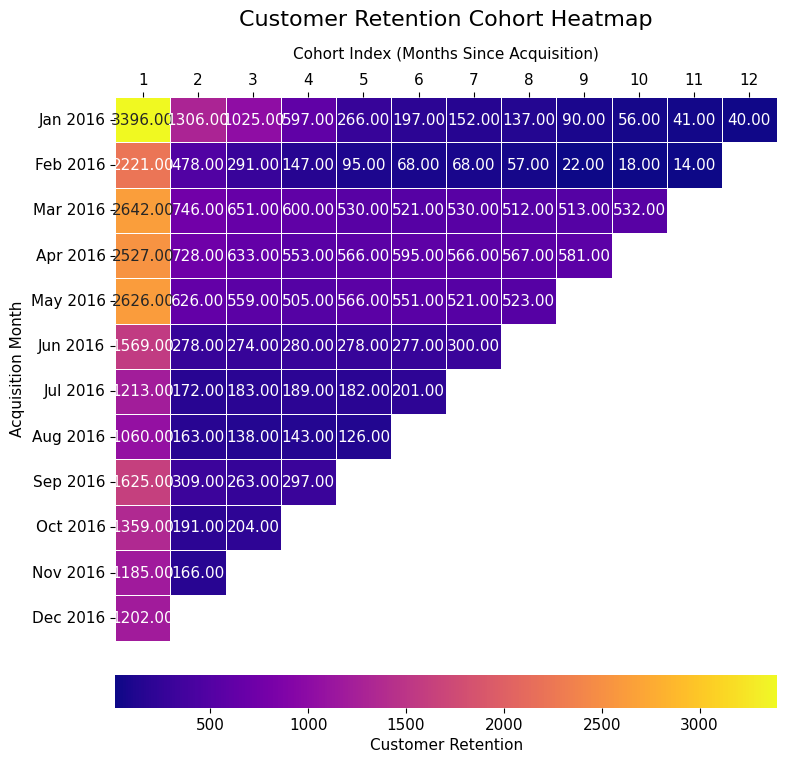

In [42]:
if __name__ == "__main__":
    cohort_counts, retention = build_cohort_matrices(df)
    plot_cohort_heatmap(cohort_counts, title="Customer Retention Cohort Heatmap", cbar_label="Customer Retention")

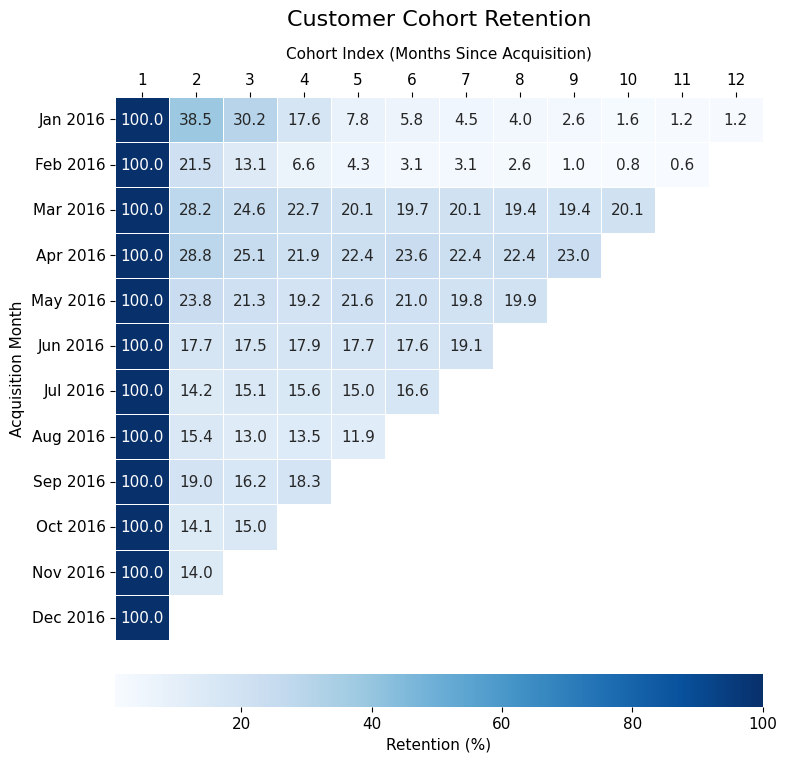

In [43]:
def plot_cohort_heatmap(retention_matrix, cbar_label="Retention (%)"):
    retention_matrix.index = pd.to_datetime(retention_matrix.index)  # Ensure index is datetime
    formatted_index = retention_matrix.index.strftime("%b %Y")       # Format Y-axis labels

    cbar_kws = {"orientation": "horizontal", "label": cbar_label, "pad": 0.05}
    plt.rcParams.update({'font.style': 'normal', 'font.size': 11 })
    cmap = random.choice(plt.colormaps()[:30])

    fig, ax = plt.subplots(figsize=(8, 8))
    ax = sns.heatmap(
        retention_matrix,
        annot=True,
        fmt=".1f",
        cmap=cmap,
        linewidths=0.5,
        linecolor="white",
        yticklabels=formatted_index,
        cbar_kws=cbar_kws
        )

    ax.set_title("Customer Cohort Retention", fontsize=16, pad=15)
    ax.set_xlabel("Cohort Index (Months Since Acquisition)", labelpad=10)
    ax.set_ylabel("Acquisition Month")

    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    plt.tight_layout()
    plt.show()

    return fig, ax

if __name__ == "__main__":
    cohort_counts, retention = build_cohort_matrices(df)
    fig, ax = plot_cohort_heatmap(
        retention_matrix = retention, 
        cbar_label="Retention (%)")

---

This analysis was performed by **Jabulente**, a passionate and dedicated data analyst with a strong commitment to using data to drive meaningful insights and solutions. For inquiries, collaborations, or further discussions, please feel free to reach out via.  

----


<h1 style='font-size: 45px; color: black; font-family: colonna MT; font-weight: 700; text-align: center'>Data to Drive Meaningful Insights and Solutions<br><span style='color: crimson; text-align: center; font-family: Cursive; font-size: 15px; font-weight: 600'>Authour: Chausiku Kassimu | Email: Chausikukassimu1@gmail.com | WhatsApp: +255 790 708 450</span></h1>